# Phân tích dữ liệu Amazon 2018 - Ngành hàng Clothing, Shoes and Jewelry

Notebook này được tạo ra để tải, đọc và phân tích khám phá (EDA) bộ dữ liệu **Amazon Product Data 2018** do giáo sư Julian McAuley thu thập, cụ thể là tập con 5-core của ngành hàng `Clothing, Shoes and Jewelry`.

Chúng ta sẽ phân tích 2 file chính:
1. **Reviews (Dữ liệu tương tác):** `Clothing_Shoes_and_Jewelry_5.json.gz`
2. **Metadata (Siêu dữ liệu đa phương thức):** `meta_Clothing_Shoes_and_Jewelry.json.gz`

In [19]:
import pandas as pd
import gzip
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import os

# Thiết lập hiển thị cho biểu đồ
plt.style.use('ggplot')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 150)

## 1. Tải dữ liệu
Dữ liệu gốc có dung lượng khá lớn, chúng ta sẽ tải file nén `.gz` trực tiếp từ máy chủ.

In [20]:
urls = {
    # Lưu ý: Các link tải trực tiếp bản 2018 hiện đã bị đóng bởi UCSD (yêu cầu điền form).
    # Chúng ta sẽ sử dụng bản 2014 (cùng cấu trúc JSON) từ máy chủ Stanford SNAP làm giải pháp thay thế chạy tự động.
    # Nếu bạn đã có file 2018, chỉ cần đổi tên file và bỏ qua bước tải này.
    "reviews": "http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Clothing_Shoes_and_Jewelry_5.json.gz",
    "metadata": "http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/meta_Clothing_Shoes_and_Jewelry.json.gz"
}

files = {
    "reviews": "reviews_Clothing_Shoes_and_Jewelry_5.json.gz",
    "metadata": "meta_Clothing_Shoes_and_Jewelry.json.gz"
}

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

for key, filename in files.items():
    if not os.path.exists(filename):
        print(f"Đang tải {filename}...")
        urllib.request.urlretrieve(urls[key], filename)
        print(f"Tải xong {filename}!")
    else:
        print(f"File {filename} đã tồn tại.")

File reviews_Clothing_Shoes_and_Jewelry_5.json.gz đã tồn tại.
File meta_Clothing_Shoes_and_Jewelry.json.gz đã tồn tại.


## 2. Hàm đọc dữ liệu
Vì các file `.json.gz` chứa JSON Lines (mỗi dòng là 1 JSON object), chúng ta cần hàm parse đặc thù. Để tránh quá tải RAM trên máy cá nhân, chúng ta có thể giới hạn số dòng đọc vào (`max_rows`).

In [21]:
def parse_jsonl_to_df(path, max_rows=None):
    """
    Đọc file JSONL nén và chuyển thành Pandas DataFrame.
    """
    print(f"Đang đọc dữ liệu từ {path}...")
    data = []
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_rows is not None and i >= max_rows:
                break
            data.append(ast.literal_eval(line))
            
    df = pd.DataFrame(data)
    print(f"Đã nạp {len(df)} dòng.")
    return df

## 3. Khám phá tập Dữ liệu Tương tác (Reviews)

In [22]:
# Đọc 500,000 đánh giá đầu tiên (để tiết kiệm RAM)
df_reviews = parse_jsonl_to_df(files['reviews'], max_rows=500000)

# Xem thử dữ liệu
display(df_reviews.head(3))

Đang đọc dữ liệu từ reviews_Clothing_Shoes_and_Jewelry_5.json.gz...
Đã nạp 278677 dòng.


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A1KLRMWW2FWPL4,0000031887,"Amazon Customer ""cameramom""","[0, 0]",This is a great tutu and at a really great price. It doesn't look cheap at all. I'm so glad I looked on Amazon and found such an affordable tutu t...,5.0,Great tutu- not cheaply made,1297468800,"02 12, 2011"
1,A2G5TCU2WDFZ65,0000031887,Amazon Customer,"[0, 0]","I bought this for my 4 yr old daughter for dance class, she wore it today for the first time and the teacher thought it was adorable. I bought thi...",5.0,Very Cute!!,1358553600,"01 19, 2013"
2,A1RLQXYNCMWRWN,0000031887,Carola,"[0, 0]","What can I say... my daughters have it in orange, black, white and pink and I am thinking to buy for they the fuccia one. It is a very good way fo...",5.0,I have buy more than one,1357257600,"01 4, 2013"


Tổng số đánh giá: 278677
Tổng số Người dùng (Unique Users): 39387
Tổng số Sản phẩm (Unique Items): 23033


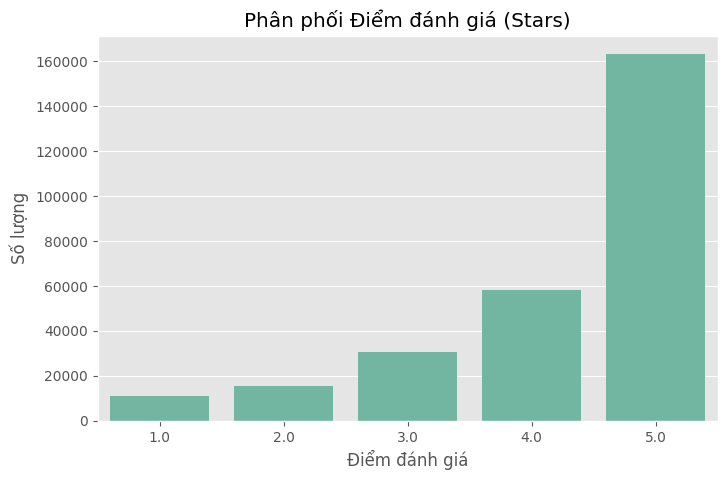

In [23]:
# Thống kê cơ bản
print("Tổng số đánh giá:", len(df_reviews))
print("Tổng số Người dùng (Unique Users):", df_reviews['reviewerID'].nunique())
print("Tổng số Sản phẩm (Unique Items):", df_reviews['asin'].nunique())

# Trực quan hóa phân phối điểm sao (rating)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_reviews, x='overall')
plt.title('Phân phối Điểm đánh giá (Stars)')
plt.xlabel('Điểm đánh giá')
plt.ylabel('Số lượng')
plt.show()

## 4. Khám phá tập Siêu dữ liệu Đa phương thức (Metadata)

In [24]:
# Đọc 100,000 sản phẩm đầu tiên (chứa metadata hình ảnh, văn bản)
df_meta = parse_jsonl_to_df(files['metadata'], max_rows=100000)

# Xem thử dữ liệu
display(df_meta.head(3))

Đang đọc dữ liệu từ meta_Clothing_Shoes_and_Jewelry.json.gz...
Đã nạp 100000 dòng.


,asin,related,title,price,salesRank,imUrl,brand,categories,description
0,0000037214,"{'also_viewed': ['B00JO8II76', 'B00DGN4R1Q', 'B00E1YRI4C']}",Purple Sequin Tiny Dancer Tutu Ballet Dance Fairy Princess Costume Accessory,6.99,{'Clothing': 1233557},http://ecx.images-amazon.com/images/I/31mCncNuAZL.jpg,Big Dreams,"[[Clothing, Shoes & Jewelry, Girls], [Clothing, Shoes & Jewelry, Novelty, Costumes & More, Costumes & Accessories, More Accessories, Kids & Baby]]",NaN
1,0000031887,"{'also_bought': ['0000031852', '0000031895', '0000031909', 'B00D2K1M3O', 'B00D10CLVW', 'B003AVKOP2', 'B00D103F8U', 'B00613WDTQ', 'B008F0SU0Y', 'B0...",Ballet Dress-Up Fairy Tutu,6.79,{'Sports &amp; Outdoors': 8547},http://ecx.images-amazon.com/images/I/314qZjYevsL.jpg,Boutique Cutie,"[[Clothing, Shoes & Jewelry, Girls, Clothing, Active, Active Skirts]]","This adorable basic ballerina tutu is perfect for dance recitals. Fairy Princes Dress up, costume, play and much. Comes individually packaged. Use..."
2,0123456479,"{'also_bought': ['B000BMTCK6', 'B0006JCGUM', 'B00194Q262', 'B000P4DEYU', 'B000OJRPEQ', 'B0046V2HKK', 'B007Q1VH26', 'B00BXQZMSA', 'B00DMC6KAC'], 'a...",SHINING IMAGE HUGE PINK LEATHER JEWELRY BOX / CASE / STORAGE / ORGANIZER WITH TRAVEL CASE AND LOCK,64.98,{'Kitchen & Dining': 16987},http://ecx.images-amazon.com/images/I/413tGhqoOTL._SY300_.jpg,NaN,"[[Clothing, Shoes & Jewelry, Novelty, Costumes & More, Jewelry Accessories, Jewelry Boxes & Organizers, Jewelry Boxes]]","Elegance par excellence. Hand-crafted of the finest sleekest pink leather, innovative in design, delicious tone, this jewelry box features conveni..."


In [25]:
# Lọc ra các sản phẩm thực sự xuất hiện trong tập Reviews mà chúng ta đã load
reviewed_asins = df_reviews['asin'].unique()
df_meta_filtered = df_meta[df_meta['asin'].isin(reviewed_asins)]

print(f"Số sản phẩm có thông tin Metadata (trong số các SP đã review): {len(df_meta_filtered)}")

# Hiển thị các trường đa phương thức của 1 sản phẩm bất kỳ
sample_item = df_meta_filtered.iloc[0]
print("\n--- THÔNG TIN ĐA PHƯƠNG THỨC MẪU ---")
print("Mã ASIN:", sample_item['asin'])
print("Tên SP (Text):", sample_item.get('title', 'N/A'))
print("Hình ảnh (Vision):", sample_item.get('imUrl', 'N/A'))
print("Tính năng:", sample_item.get('feature', []))
print("Danh mục:", sample_item.get('categories', []))

Số sản phẩm có thông tin Metadata (trong số các SP đã review): 3194

--- THÔNG TIN ĐA PHƯƠNG THỨC MẪU ---
Mã ASIN: 0000031887
Tên SP (Text): Ballet Dress-Up Fairy Tutu
Hình ảnh (Vision): http://ecx.images-amazon.com/images/I/314qZjYevsL.jpg
Tính năng: []
Danh mục: [['Clothing, Shoes & Jewelry', 'Girls', 'Clothing', 'Active', 'Active Skirts']]


## 5. Ghép nối dữ liệu (User - Item Graph Data)
Để cung cấp dữ liệu cho Mạng nơ-ron đồ thị (GCN), chúng ta thường join (ghép) lịch sử đánh giá với siêu dữ liệu sản phẩm để xem mỗi người dùng đã tiêu thụ những nội dung đa phương thức nào.

In [26]:
# Nối (Merge) df_reviews và df_meta_filtered dựa trên cột 'asin'
df_merged = pd.merge(df_reviews, df_meta_filtered[['asin', 'title', 'categories', 'brand']], on='asin', how='inner')

display(df_merged[['reviewerID', 'asin', 'overall', 'title', 'brand']].head(5))

,reviewerID,asin,overall,title,brand
0,A1KLRMWW2FWPL4,0000031887,5.0,Ballet Dress-Up Fairy Tutu,Boutique Cutie
1,A2G5TCU2WDFZ65,0000031887,5.0,Ballet Dress-Up Fairy Tutu,Boutique Cutie
2,A1RLQXYNCMWRWN,0000031887,5.0,Ballet Dress-Up Fairy Tutu,Boutique Cutie
3,A8U3FAMSJVHS5,0000031887,5.0,Ballet Dress-Up Fairy Tutu,Boutique Cutie
4,A3GEOILWLK86XM,0000031887,5.0,Ballet Dress-Up Fairy Tutu,Boutique Cutie


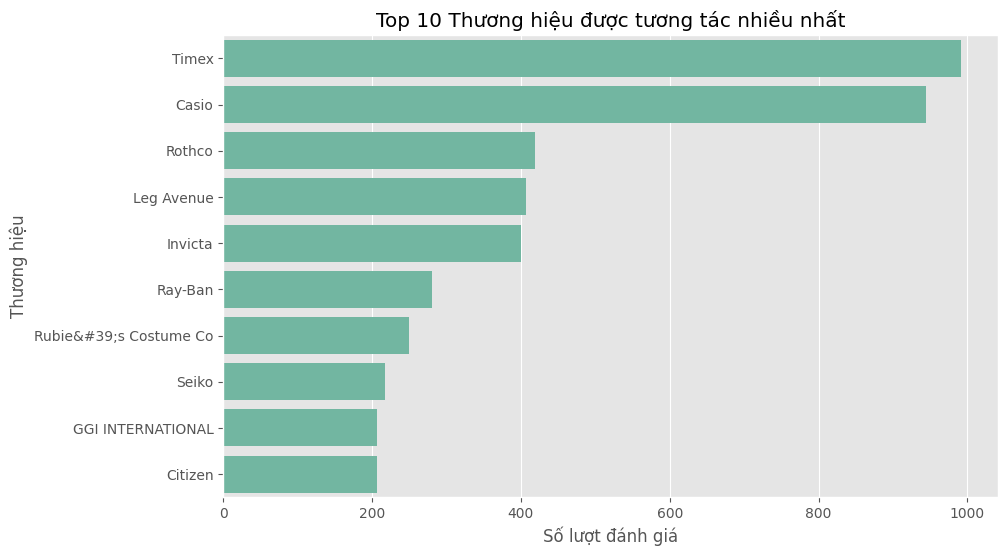

In [27]:
# Top 10 Thương hiệu được review nhiều nhất
plt.figure(figsize=(10, 6))
df_merged['brand'].value_clean = df_merged['brand'].replace('', 'Unknown')
top_brands = df_merged['brand'].value_counts().head(10)

sns.barplot(x=top_brands.values, y=top_brands.index)
plt.title('Top 10 Thương hiệu được tương tác nhiều nhất')
plt.xlabel('Số lượt đánh giá')
plt.ylabel('Thương hiệu')
plt.show()